# 03 - Train Notebook (Local)
Notebook khoi dong va theo doi qua trinh train DeepfakeDetector tren may local.

## Cell 1 - Setup

In [9]:
# Muc dich: setup path, load config va set seed theo cau hinh.
import os
import random
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import yaml
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import clear_output, display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'configs').exists() and (PROJECT_ROOT.parent / 'configs').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from data.augmentation import get_train_transform, get_val_transform
from data.dataset import DeepfakeDataset
from models.deepfake_model import DeepfakeDetector
from training.loss import FocalLossWithSmoothing
from training.trainer import Trainer

sns.set_theme(style='whitegrid', context='notebook')

MODEL_CFG_PATH = PROJECT_ROOT / 'configs' / 'model_config.yaml'
TRAIN_CFG_PATH = PROJECT_ROOT / 'configs' / 'train_config.yaml'

with open(MODEL_CFG_PATH, 'r', encoding='utf-8') as f:
    model_cfg = yaml.safe_load(f)
with open(TRAIN_CFG_PATH, 'r', encoding='utf-8') as f:
    train_cfg = yaml.safe_load(f)

exp_cfg = train_cfg.get('experiment', {})
seed = int(exp_cfg.get('seed', 42))
deterministic = bool(exp_cfg.get('deterministic', True))

def set_seed(seed_value=42, deterministic_mode=True):
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    torch.cuda.manual_seed_all(seed_value)
    torch.backends.cudnn.deterministic = deterministic_mode
    torch.backends.cudnn.benchmark = not deterministic_mode

set_seed(seed, deterministic)
print('PROJECT_ROOT :', PROJECT_ROOT)
print('Seed        :', seed)
print('Deterministic:', deterministic)


PROJECT_ROOT : /root/ai_env/deepfake_detector
Seed        : 42
Deterministic: True


## Cell 2 - Kiem Tra GPU

In [2]:
# Muc dich: in thong tin GPU/VRAM va uoc tinh batch size an toan.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

if device.type == 'cuda':
    gpu_idx = torch.cuda.current_device()
    props = torch.cuda.get_device_properties(gpu_idx)
    total_vram_gb = props.total_memory / (1024 ** 3)

    free_bytes, total_bytes = torch.cuda.mem_get_info(gpu_idx)
    free_vram_gb = free_bytes / (1024 ** 3)

    print('GPU name      :', torch.cuda.get_device_name(gpu_idx))
    print(f'VRAM total    : {total_vram_gb:.2f} GB')
    print(f'VRAM available: {free_vram_gb:.2f} GB')

    # Heuristic don gian: voi EfficientNet-B4 + sequence, moi 1 sample ton ~0.5-0.7GB tuy setup.
    est_safe_bs = max(1, int(free_vram_gb / 0.65))
    print('Estimated safe batch_size ~', est_safe_bs)

    if total_vram_gb < 6.0:
        print('[CANH BAO] VRAM < 6GB: nen giam batch_size hoac tang gradient accumulation.')
else:
    print('Khong co GPU CUDA. Preprocess/train se chay CPU (rat cham).')
    est_safe_bs = 1


Device: cuda
GPU name      : NVIDIA RTX A5000
VRAM total    : 23.56 GB
VRAM available: 23.34 GB
Estimated safe batch_size ~ 35


## Cell 3 - Khoi Tao Dataset va DataLoader

In [9]:
import os
from PIL import Image
from pathlib import Path
from tqdm.auto import tqdm

# Trỏ tới thư mục chứa toàn bộ ảnh của bạn
data_dir = Path("/root/ai_env/deepfake_detector/processed_faces")

print("Đang quét toàn bộ ảnh để tìm file lỗi...")
# Tìm tất cả file .jpg và .png
image_files = list(data_dir.rglob("*.jpg")) + list(data_dir.rglob("*.png"))

bad_files = []

for img_path in tqdm(image_files, desc="Kiểm tra ảnh"):
    try:
        # Mở và verify header của ảnh (nhanh hơn nhiều so với việc load toàn bộ ảnh)
        with Image.open(img_path) as img:
            img.verify()
    except Exception:
        # Nếu có bất kỳ lỗi nào (UnidentifiedImageError, OSError...), đưa vào danh sách đen
        bad_files.append(img_path)

print(f"\nPhát hiện {len(bad_files)} file bị hỏng.")

# Xóa các file lỗi
for bad_file in bad_files:
    try:
        os.remove(bad_file)
        print(f" Đã xóa: {bad_file.name}")
    except Exception as e:
        print(f" Không thể xóa {bad_file.name}: {e}")

print("Hoàn tất dọn dẹp dataset! Bạn có thể chạy lại cell DataLoader ở trên.")

Đang quét toàn bộ ảnh để tìm file lỗi...


Kiểm tra ảnh: 100%|██████████| 265740/265740 [00:30<00:00, 8789.48it/s]


Phát hiện 2628 file bị hỏng.
 Đã xóa: id7_0009_f0009.jpg
 Đã xóa: boobpetndu_f0009.jpg
 Đã xóa: boobpetndu_f0000.jpg
 Đã xóa: jawgcggquk_f0005.jpg
 Đã xóa: id16_0004_f0000.jpg
 Đã xóa: 00198_f0009.jpg
 Đã xóa: 00198_f0002.jpg
 Đã xóa: 00198_f0001.jpg
 Đã xóa: id52_0002_f0006.jpg
 Đã xóa: id26_0003_f0008.jpg
 Đã xóa: id26_0003_f0009.jpg
 Đã xóa: nwhleyjguj_f0009.jpg
 Đã xóa: tohrqjyter_f0004.jpg
 Đã xóa: tohrqjyter_f0005.jpg
 Đã xóa: nrnklcxdzq_f0006.jpg
 Đã xóa: nrnklcxdzq_f0008.jpg
 Đã xóa: nrnklcxdzq_f0009.jpg
 Đã xóa: nrnklcxdzq_f0005.jpg
 Đã xóa: alfjkgcvle_f0009.jpg
 Đã xóa: id33_0004_f0000.jpg
 Đã xóa: sqsaiehvhb_f0004.jpg
 Đã xóa: id53_0002_f0004.jpg
 Đã xóa: 00109_f0004.jpg
 Đã xóa: dskfqergbt_f0004.jpg
 Đã xóa: jrabtkjqwn_f0009.jpg
 Đã xóa: djmyetudka_f0006.jpg
 Đã xóa: qzjpcshjjr_f0003.jpg
 Đã xóa: dxgnpnowgk_f0004.jpg
 Đã xóa: dxgnpnowgk_f0006.jpg
 Đã xóa: id43_0006_f0001.jpg
 Đã xóa: jjycletzyl_f0002.jpg
 Đã xóa: nojgizgrbw_f0003.jpg
 Đã xóa: id10_0000_f0009.jpg
 Đã xóa: x

Train samples: 9584
Val samples  : 2053
Train class distribution (0=Real,1=Fake): Counter({1: 6465, 0: 3119})
Val class distribution   (0=Real,1=Fake): Counter({1: 1385, 0: 668})


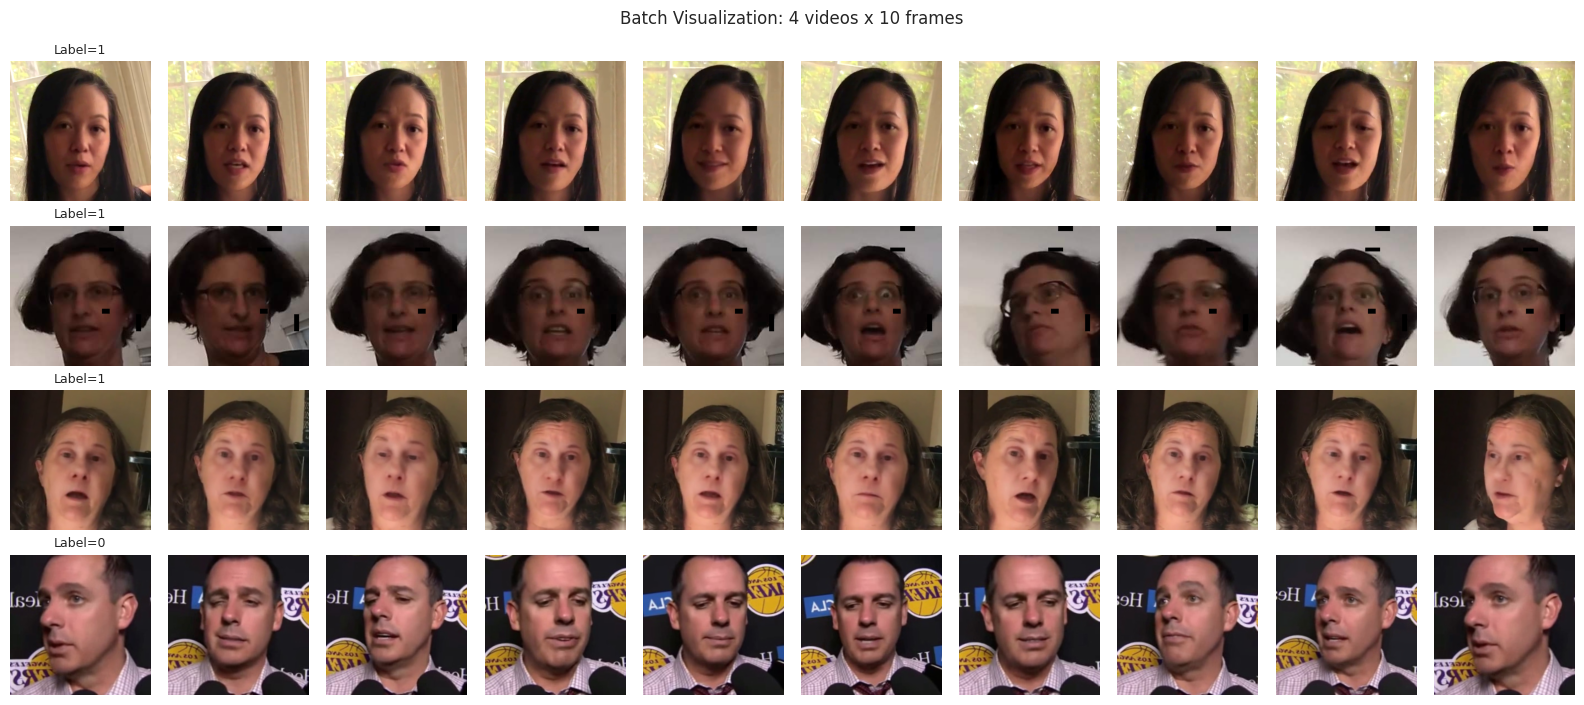

Same seed -> same video sample equal?: True
Different seed -> sample equal?: False


In [3]:
# Muc dich: tao train/val dataset-loader, in class distribution va visualize 1 batch.
from collections import Counter
import random
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler
import albumentations as A  # Import thêm Albumentations để can thiệp bộ RNG

# Import đúng hàm xử lý theo Clip (Video) để đảm bảo Spatial Consistency
from data.augmentation import get_train_clip_transform, get_val_clip_transform
from data.dataset import DeepfakeDataset

data_cfg = train_cfg.get('data', {})
training_cfg = train_cfg.get('training', {})
model_main_cfg = model_cfg.get('model', {})

input_cfg = model_main_cfg.get('input', {})
img_size = int(input_cfg.get('img_size', model_main_cfg.get('image_size', 256)))
num_frames = int(input_cfg.get('num_frames', model_main_cfg.get('num_frames', 10)))

batch_size = int(training_cfg.get('batch_size', 8))
num_workers = int(data_cfg.get('num_workers', 4))
pin_memory = bool(data_cfg.get('pin_memory', True)) and (device.type == 'cuda')
prefetch_factor = int(data_cfg.get('prefetch_factor', 2))

train_dir = Path(PROJECT_ROOT) / 'processed_faces/train'
val_dir_cfg = Path(PROJECT_ROOT) / 'processed_faces/val'

# Khởi tạo Video/Clip Transforms 
train_clip_tf = get_train_clip_transform(img_size=img_size)
val_clip_tf = get_val_clip_transform(img_size=img_size)

def stratified_split_indices(labels, val_ratio=0.15, seed_value=42):
    rng = random.Random(seed_value)
    labels = list(labels)
    idx_by_class = {}
    for i, y in enumerate(labels):
        idx_by_class.setdefault(int(y), []).append(i)

    train_idx, val_idx = [], []
    for cls, idxs in idx_by_class.items():
        rng.shuffle(idxs)
        n_val = max(1, int(round(len(idxs) * val_ratio))) if len(idxs) > 1 else 0
        val_part = idxs[:n_val]
        train_part = idxs[n_val:]
        if len(train_part) == 0 and len(val_part) > 0:
            train_part = [val_part.pop()]
        train_idx.extend(train_part)
        val_idx.extend(val_part)

    rng.shuffle(train_idx)
    rng.shuffle(val_idx)
    return train_idx, val_idx

def extract_labels_from_dataset(ds):
    if isinstance(ds, Subset):
        base_labels = ds.dataset.get_labels()
        return [base_labels[i] for i in ds.indices]
    return ds.get_labels()

# Truyền clip_transform vào Dataset
train_base = DeepfakeDataset(
    str(train_dir), 
    num_frames=num_frames, 
    clip_transform=train_clip_tf, 
    mode='train'
)

if not val_dir_cfg.exists():
    val_base = DeepfakeDataset(str(train_dir), num_frames=num_frames, clip_transform=val_clip_tf, mode='val')
    all_labels = train_base.get_labels()
    train_idx, val_idx = stratified_split_indices(all_labels, val_ratio=val_split, seed_value=seed)
    train_dataset = Subset(train_base, train_idx)
    val_dataset = Subset(val_base, val_idx)
else:
    val_root = val_dir_cfg
    train_dataset = train_base
    val_dataset = DeepfakeDataset(str(val_root), num_frames=num_frames, clip_transform=val_clip_tf, mode='val')

train_labels = extract_labels_from_dataset(train_dataset)
val_labels = extract_labels_from_dataset(val_dataset)

train_counts = np.bincount(np.asarray(train_labels, dtype=np.int64), minlength=2)
class_weights = np.zeros_like(train_counts, dtype=np.float64)
non_zero = train_counts > 0
class_weights[non_zero] = 1.0 / train_counts[non_zero]
sample_weights = class_weights[np.asarray(train_labels, dtype=np.int64)]
sampler = WeightedRandomSampler(weights=torch.as_tensor(sample_weights, dtype=torch.double), num_samples=len(sample_weights), replacement=True)

dl_kwargs = dict(batch_size=batch_size, num_workers=num_workers, pin_memory=pin_memory, drop_last=False)
if num_workers > 0:
    dl_kwargs['persistent_workers'] = True
    dl_kwargs['prefetch_factor'] = prefetch_factor

train_loader = DataLoader(train_dataset, sampler=sampler, shuffle=False, **dl_kwargs)
val_loader = DataLoader(val_dataset, shuffle=False, **dl_kwargs)

print('Train samples:', len(train_dataset))
print('Val samples  :', len(val_dataset))
print('Train class distribution (0=Real,1=Fake):', Counter(train_labels))
print('Val class distribution   (0=Real,1=Fake):', Counter(val_labels))

# Visualize 1 batch
batch_frames, batch_labels = next(iter(train_loader))
show_b = min(4, batch_frames.shape[0])
show_t = min(10, batch_frames.shape[1])

mean = torch.tensor([0.485, 0.456, 0.406], dtype=batch_frames.dtype).view(1,1,3,1,1)
std = torch.tensor([0.229, 0.224, 0.225], dtype=batch_frames.dtype).view(1,1,3,1,1)
vis = (batch_frames[:show_b, :show_t] * std + mean).clamp(0, 1)

fig, axes = plt.subplots(show_b, show_t, figsize=(show_t * 1.6, show_b * 1.8))
axes = np.array(axes).reshape(show_b, show_t)
for r in range(show_b):
    for c in range(show_t):
        axes[r, c].imshow(vis[r, c].permute(1, 2, 0).cpu().numpy())
        axes[r, c].axis('off')
        if c == 0:
            axes[r, c].set_title(f'Label={int(batch_labels[r])}', fontsize=9)
fig.suptitle('Batch Visualization: 4 videos x 10 frames', fontsize=12)
plt.tight_layout()
plt.show()

# ==========================================
# TEST AUGMENTATION REPRODUCIBILITY (ĐÃ FIX CHO ALBU >= 1.4)
# ==========================================
test_idx = 0
def get_item_with_seed(ds, idx, seed_value):
    # 1. Reset Global Seeds
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    
    # 2. Reset Object-Oriented Seed của Albumentations (>= 1.4.0)
    # Quét đệ quy để tìm object A.ReplayCompose/A.Compose đang nấp bên trong clip_transform
    def apply_albu_seed(obj, seed):
        if hasattr(obj, 'set_random_seed'):
            obj.set_random_seed(seed)
        elif hasattr(obj, '__dict__'):
            for attr_val in obj.__dict__.values():
                if hasattr(attr_val, 'set_random_seed'):
                    attr_val.set_random_seed(seed)
                    
    # Áp dụng hàm quét vào clip_transform của dataset
    if hasattr(ds, 'clip_transform'):
        apply_albu_seed(ds.clip_transform, seed_value)
    
    x, y = ds[idx]
    return x, y

base_ds = train_base if not isinstance(train_dataset, Subset) else train_dataset.dataset

# Gọi thử 3 lần
x1, y1 = get_item_with_seed(base_ds, test_idx, 123)
x2, y2 = get_item_with_seed(base_ds, test_idx, 123)
x3, y3 = get_item_with_seed(base_ds, test_idx, 999)

same_seed_equal = torch.allclose(x1, x2) and (y1 == y2)
diff_seed_equal = torch.allclose(x1, x3) and (y1 == y3)

print('Same seed -> same video sample equal?:', same_seed_equal)
print('Different seed -> sample equal?:', diff_seed_equal)

## Cell 4 - Khoi Tao Model

In [4]:
# Muc dich: khoi tao DeepfakeDetector tu config va test forward shape.
eff_cfg = model_main_cfg.get('efficientnet', {})
tf_cfg = model_main_cfg.get('transformer', {})

model_name = str(eff_cfg.get('model_name', 'efficientnet_b4'))
feat_dim_map = {'efficientnet_b0': 1280, 'efficientnet_b4': 1792}
feat_dim = int(model_main_cfg.get('feat_dim', feat_dim_map.get(model_name, 1792)))
dropout = float(eff_cfg.get('dropout', tf_cfg.get('dropout', 0.3)))

model = DeepfakeDetector(
    feat_dim=feat_dim,
    d_model=int(tf_cfg.get('d_model', 512)),
    nhead=int(tf_cfg.get('nhead', 8)),
    num_layers=int(tf_cfg.get('num_layers', 4)),
    dropout=dropout,
    num_frames=num_frames,
)

if bool(eff_cfg.get('freeze_at_start', False)):
    model.backbone.freeze_backbone()

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params = total_params - trainable_params

print(f'Total params    : {total_params:,}')
print(f'Trainable params: {trainable_params:,}')
print(f'Frozen params   : {frozen_params:,}')

dummy = torch.randn(2, num_frames, 3, img_size, img_size)
with torch.no_grad():
    out = model(dummy)
print('Dummy input shape :', tuple(dummy.shape))
print('Model output shape:', tuple(out.shape))

model = model.to(device)


Total params    : 31,083,849
Trainable params: 13,535,233
Frozen params   : 17,548,616
Dummy input shape : (2, 10, 3, 256, 256)
Model output shape: (2,)


## Cell 4.5 - (Optional) Resume Tu Checkpoint

In [5]:
# Neu ban muon resume tu checkpoint, chinh duong dan va chay cell nay.
import os

RESUME_CKPT = PROJECT_ROOT / 'checkpoints' / 'dfdc_efficientnet_transformer_v1_best_epoch001_auc0_660690.pth'
resume_meta = None

# Kiểm tra xem file có thực sự tồn tại trước khi load
if RESUME_CKPT.exists():
    resume_meta = model.load_checkpoint(str(RESUME_CKPT))
    print('Da load checkpoint:', RESUME_CKPT)
    
    # In ra các thông số (như epoch, val_auc) để bạn biết model đã train đến đâu
    if resume_meta:
        print("Thông tin Checkpoint:")
        for k, v in resume_meta.items():
            if k not in ['model_state_dict', 'optimizer_state_dict', 'scheduler_state_dict']: # Ẩn bớt các mảng số khổng lồ
                print(f" - {k}: {v}")
else:
    print(f'Khong tim thay checkpoint tai: {RESUME_CKPT}')
    print('Vui long kiem tra lai ten file hoac thu muc luu.')
    RESUME_CKPT = None # Reset ve None de tránh loi

/root/ai_env/deepfake_detector/models/deepfake_model.py:161: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(ckpt_path, map_location="cpu")


Da load checkpoint: /root/ai_env/deepfake_detector/checkpoints/dfdc_efficientnet_transformer_v1_best_epoch001_auc0_660690.pth
Thông tin Checkpoint:
 - epoch: 1
 - val_auc: 0.6606904040998427
 - missing_keys: []
 - unexpected_keys: []


## Cell 5 - Training Loop

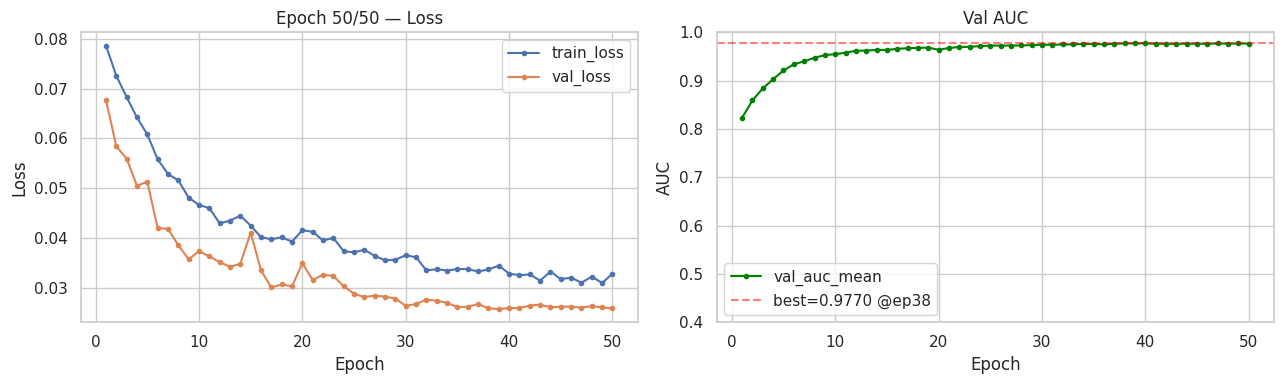

Ep 50/50 | train_loss=0.0328 | val_loss=0.0258 | val_auc_mean=0.9767 | val_auc_max=0.9767 | lr=1.00e-07 | no_improve=12/20
Best checkpoint loaded: epoch=38, val_auc=0.9770
Best epoch: 38
Best val_auc: 0.9769990704511554
Checkpoint saved at: /root/ai_env/deepfake_detector/checkpoints/dfdc_efficientnet_transformer_v1_best.pth


/root/ai_env/deepfake_detector/models/deepfake_model.py:161: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(ckpt_path, map_location="cpu")


In [6]:
# Muc dich: khoi tao Trainer + callbacks va train voi real-time loss plot.
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR

opt_cfg = train_cfg.get('optimizer', {})
sch_cfg = train_cfg.get('scheduler', {})
loss_cfg = train_cfg.get('loss', {})
ckpt_cfg = train_cfg.get('checkpoint', {})

num_epochs = int(training_cfg.get('num_epochs', 20))
patience = int(training_cfg.get('patience', 5))
min_delta = float(training_cfg.get('min_delta', 0.0))
grad_clip = float(training_cfg.get('gradient_clip_val', 1.0))
precision = int(training_cfg.get('precision', 16))

lr_backbone = float(opt_cfg.get('lr_backbone', 1e-5))
lr_head = float(opt_cfg.get('lr_head', 1e-4))
weight_decay = float(opt_cfg.get('weight_decay', 0.01))
betas = tuple(opt_cfg.get('betas', [0.9, 0.999]))

param_groups = model.get_optimizer_groups(lr_backbone=lr_backbone, lr_head=lr_head)
optimizer = AdamW(param_groups, weight_decay=weight_decay, betas=betas)

t_max = int(sch_cfg.get('T_max', num_epochs))
eta_min = float(sch_cfg.get('eta_min', 1e-7))
warmup_epochs = int(sch_cfg.get('warmup_epochs', 0))

if warmup_epochs > 0:
    warmup = LinearLR(optimizer, start_factor=0.1, end_factor=1.0, total_iters=warmup_epochs)
    cosine = CosineAnnealingLR(optimizer, T_max=max(1, t_max - warmup_epochs), eta_min=eta_min)
    scheduler = SequentialLR(optimizer, schedulers=[warmup, cosine], milestones=[warmup_epochs])
else:
    scheduler = CosineAnnealingLR(optimizer, T_max=max(1, t_max), eta_min=eta_min)

criterion = FocalLossWithSmoothing(
    gamma=float(loss_cfg.get('gamma', 2.0)),
    alpha=float(loss_cfg.get('alpha', 0.75)),   # ← đổi default từ 0.25 → 0.75
    smoothing=float(loss_cfg.get('smoothing', 0.1)),
)


# Ép buộc lưu vào thư mục checkpoints bên trong ai_env/deepfake_detector
save_dir = Path(PROJECT_ROOT) / 'checkpoints'
save_dir.mkdir(parents=True, exist_ok=True)
ckpt_path = save_dir / f"{exp_cfg.get('name', 'exp')}_best.pth"

class Callback:
    def on_epoch_end(self, state):
        pass
    def on_train_end(self, state):
        pass

class BestEpochCallback(Callback):
    def on_epoch_end(self, state):
        if state.get('is_best', False):
            print(f"[Callback] New best at epoch {state['epoch']}: val_auc={state['val_auc']:.4f}")

class NotebookTrainer(Trainer):
    def __init__(self, *args, callbacks=None, live_plot=True, **kwargs):
        super().__init__(*args, **kwargs)
        self.callbacks = callbacks or []
        self.live_plot = bool(live_plot)
        self.history = {
            'epoch': [], 'train_loss': [], 'val_loss': [],
            'val_auc': [], 'lr': []
        }
        self.stopped_epoch = None

    def fit(self, num_epochs: int, start_epoch: int = 1):
        epochs_no_improve = 0
        end_epoch = start_epoch + num_epochs - 1

        for epoch in range(start_epoch, end_epoch + 1):
            # [FIX 1] Truyền current_epoch để kích hoạt unfreeze backbone đúng epoch
            train_metrics = self.train_one_epoch(current_epoch=epoch)
            val_metrics   = self.validate()

            if self.scheduler is not None:
                from torch.optim.lr_scheduler import ReduceLROnPlateau
                if isinstance(self.scheduler, ReduceLROnPlateau):
                    self.scheduler.step(val_metrics['auc_mean'])
                else:
                    self.scheduler.step()

            current_lr = float(self.optimizer.param_groups[0]['lr'])

            # Dùng auc_mean (tương thích multi-clip) làm monitor chính
            monitor_auc = float(val_metrics.get('auc_mean', val_metrics.get('auc', 0.0)))

            # [FIX 2] Guard giống Trainer gốc — chỉ lưu khi AUC có ý nghĩa
            is_best = (
                monitor_auc > (self.best_val_auc + self.min_delta)
                and monitor_auc > 0.5
            )
            if is_best:
                self.best_val_auc = monitor_auc
                self.best_epoch   = epoch
                epochs_no_improve = 0
                self._save_best_checkpoint(epoch=epoch, val_auc=self.best_val_auc)
            else:
                epochs_no_improve += 1

            # Ghi history
            self.history['epoch'].append(epoch)
            self.history['train_loss'].append(train_metrics['loss'])
            self.history['val_loss'].append(val_metrics['loss'])
            self.history['val_auc'].append(monitor_auc)
            self.history['lr'].append(current_lr)

            # Live plot
            if self.live_plot:
                clear_output(wait=True)
                fig, axes = plt.subplots(1, 2, figsize=(13, 4))

                axes[0].plot(self.history['epoch'], self.history['train_loss'],
                             label='train_loss', marker='o', ms=3)
                axes[0].plot(self.history['epoch'], self.history['val_loss'],
                             label='val_loss', marker='o', ms=3)
                axes[0].set_title(f'Epoch {epoch}/{end_epoch} — Loss')
                axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
                axes[0].legend()

                axes[1].plot(self.history['epoch'], self.history['val_auc'],
                             label='val_auc_mean', color='green', marker='o', ms=3)
                axes[1].axhline(y=self.best_val_auc, color='red',
                                linestyle='--', alpha=0.5,
                                label=f'best={self.best_val_auc:.4f} @ep{self.best_epoch}')
                axes[1].set_title('Val AUC')
                axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('AUC')
                axes[1].set_ylim(0.4, 1.0)
                axes[1].legend()

                plt.tight_layout(); plt.show()

            # Log
            auc_max = float(val_metrics.get('auc_max', monitor_auc))
            print(
                f"Ep {epoch}/{end_epoch} | "
                f"train_loss={train_metrics['loss']:.4f} | "
                f"val_loss={val_metrics['loss']:.4f} | "
                f"val_auc_mean={monitor_auc:.4f} | "
                f"val_auc_max={auc_max:.4f} | "
                f"lr={current_lr:.2e} | "
                f"no_improve={epochs_no_improve}/{self.patience}"
            )

            state = {
                'epoch': epoch, 'train_loss': train_metrics['loss'],
                'val_loss': val_metrics['loss'], 'val_auc': monitor_auc,
                'lr': current_lr, 'is_best': is_best,
                'best_epoch': self.best_epoch, 'best_val_auc': self.best_val_auc,
                'epochs_no_improve': epochs_no_improve,
            }
            for cb in self.callbacks:
                cb.on_epoch_end(state)

            if epochs_no_improve >= self.patience:
                self.stopped_epoch = epoch
                print(f'Early stopping at epoch {epoch} (patience={self.patience}).')
                break

        if self.load_best_at_end and self.best_epoch >= 1:
            self._load_best_checkpoint_into_model()
            print(f'Best checkpoint loaded: epoch={self.best_epoch}, '
                  f'val_auc={self.best_val_auc:.4f}')

        final_state = {
            'best_epoch': self.best_epoch,
            'best_val_auc': self.best_val_auc,
            'history': self.history,
            'checkpoint_path': str(self.checkpoint_path),
        }
        for cb in self.callbacks:
            cb.on_train_end(final_state)
        return final_state

callbacks = [BestEpochCallback()]

model_cfg       = train_cfg.get('model', {})
efficientnet_cfg = model_cfg.get('efficientnet', {})

trainer = NotebookTrainer(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    scheduler=scheduler,
    criterion=criterion,
    device=device,
    config={
        'patience':               patience,
        'min_delta':              min_delta,
        'max_grad_norm':          grad_clip,
        'checkpoint_path':        str(ckpt_path),
        'use_amp':                (precision == 16),
        'accumulate_grad_batches': int(training_cfg.get('accumulate_grad_batches', 1)),
        'save_top_k':             int(ckpt_cfg.get('save_top_k', 3)),
        # Unfreeze config — đọc từ model_config
        'unfreeze_after_epoch':   int(efficientnet_cfg.get('unfreeze_after_epoch', 5)),
        'unfreeze_last_n_blocks': int(efficientnet_cfg.get('unfreeze_last_n_blocks', 2)),
        'unfreeze_backbone_lr':   lr_backbone,
    },
    callbacks=callbacks,
    live_plot=True,
)

if resume_meta is not None and isinstance(resume_meta, dict):
    if resume_meta.get('val_auc') is not None:
        trainer.best_val_auc = float(resume_meta['val_auc'])

result = trainer.fit(num_epochs=num_epochs)
history = result['history']
print('Best epoch:', result['best_epoch'])
print('Best val_auc:', result['best_val_auc'])
print('Checkpoint saved at:', result['checkpoint_path'])


## Cell 6 - Theo Doi Ket Qua

,epoch,train_loss,val_loss,val_auc,lr
45,46,0.032012,0.026182,0.976406,9.864941e-07
46,47,0.030990,0.025994,0.977056,5.999555e-07
47,48,0.032221,0.026262,0.976562,3.226167e-07
48,49,0.030936,0.026023,0.976982,1.557164e-07
49,50,0.032811,0.025830,0.976743,1.000000e-07


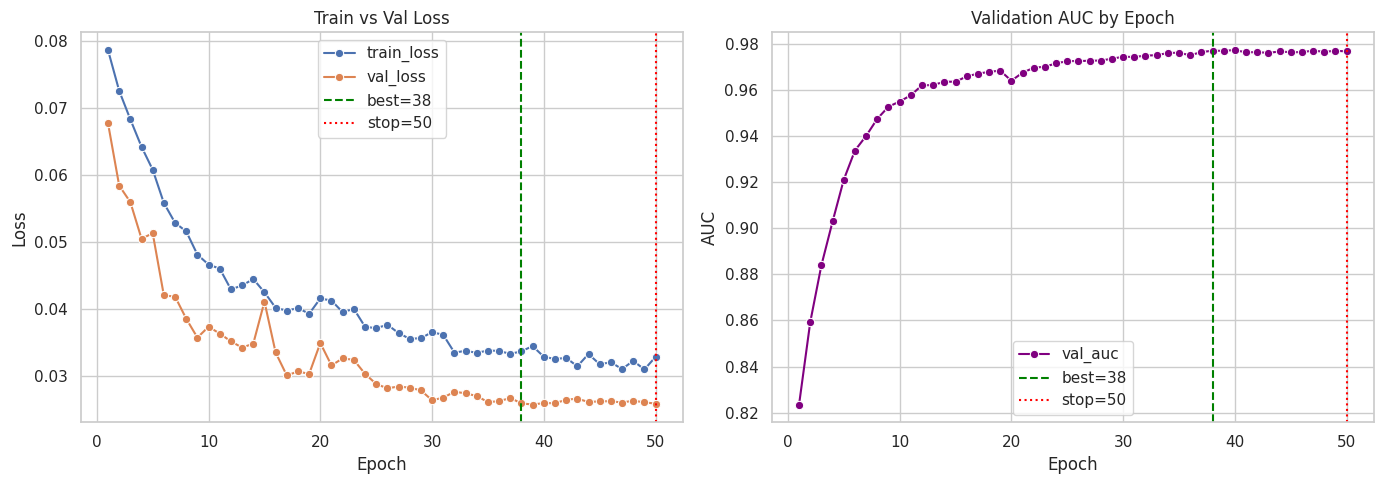

In [8]:
# Muc dich: ve cac duong train_loss/val_loss, val_auc va danh dau best + early stopping epoch.
hist_df = pd.DataFrame(history)
display(hist_df.tail())

best_epoch   = int(result['best_epoch'])
stopped_epoch = int(result.get('stopped_epoch', hist_df['epoch'].max()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(data=hist_df, x='epoch', y='train_loss', marker='o', ax=axes[0], label='train_loss')
sns.lineplot(data=hist_df, x='epoch', y='val_loss', marker='o', ax=axes[0], label='val_loss')
axes[0].axvline(best_epoch, color='green', linestyle='--', label=f'best={best_epoch}')
axes[0].axvline(stopped_epoch, color='red', linestyle=':', label=f'stop={stopped_epoch}')
axes[0].set_title('Train vs Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

sns.lineplot(data=hist_df, x='epoch', y='val_auc', marker='o', ax=axes[1], color='purple', label='val_auc')
axes[1].axvline(best_epoch, color='green', linestyle='--', label=f'best={best_epoch}')
axes[1].axvline(stopped_epoch, color='red', linestyle=':', label=f'stop={stopped_epoch}')
axes[1].set_title('Validation AUC by Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC')
axes[1].legend()

plt.tight_layout()
plt.show()
